# **Conversor de Moeda API**

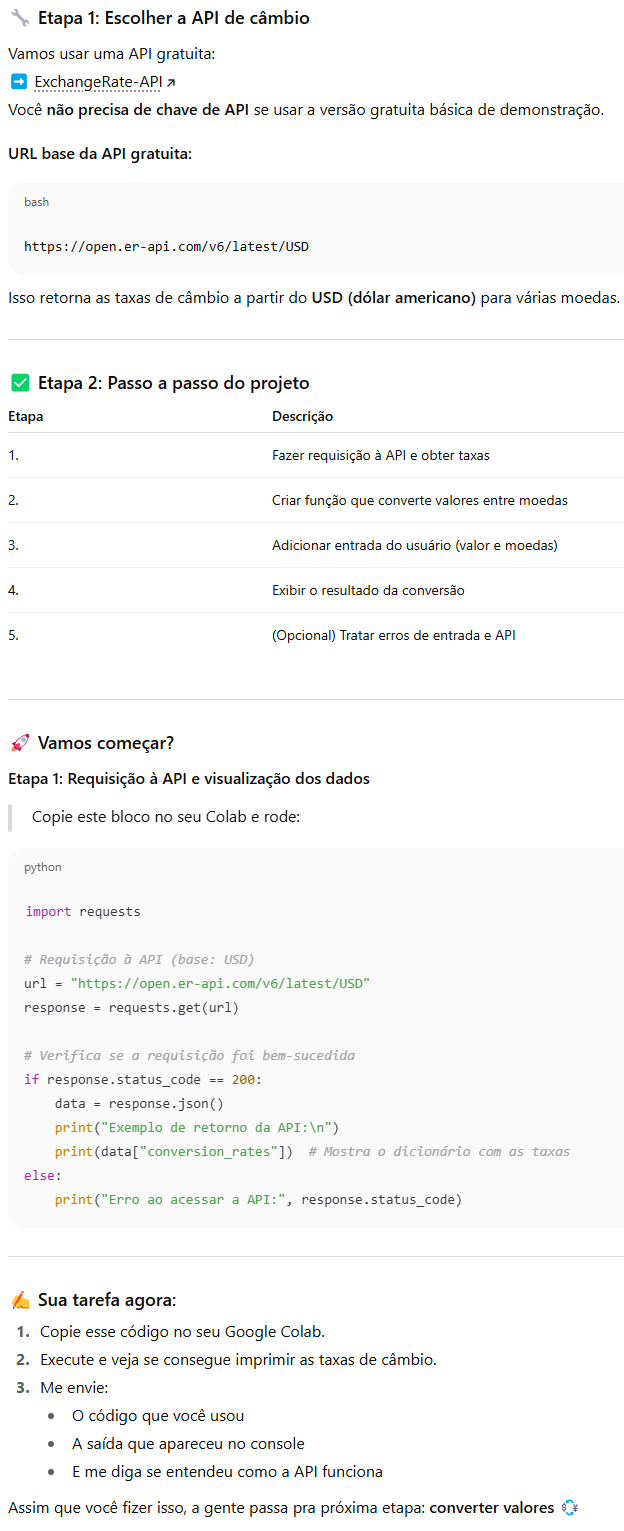

In [ ]:
import requests
from itertools import zip_longest


dict_moedas = {}

# URL da API com base em USD
url = "https://open.er-api.com/v6/latest/USD"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    rates = data["rates"]

    dict_moedas = {moeda: valor for moeda, valor in rates.items()}

    # Gerar lista formatada com strings tipo "BRL: 5.43"
    linhas = [f"{moeda}: {valor:.2f}" for moeda, valor in dict_moedas.items()]

    # Dividir a lista em blocos de 20 (cada bloco será uma coluna)
    colunas = [linhas[i:i+20] for i in range(0, len(linhas), 20)]

    # Mostrar cabeçalho
    print("✅ Taxas de câmbio disponíveis:\n")

    # Imprimir colunas verticalmente, lado a lado
    for linha in zip_longest(*colunas, fillvalue=""):
        print("".join(f"{item:<25}" for item in linha))

else:
    print("Erro ao acessar a API:", response.status_code)

def converter_moeda(valor, moeda_origem, moeda_destino, taxas):
    try:
        # Obtém a taxa da moeda de origem para o dólar
        taxa_origem = taxas[moeda_origem.upper()]
        # Obtém a taxa da moeda de destino para o dólar
        taxa_destino = taxas[moeda_destino.upper()]
        # Primeiro, converte para USD (se necessário), depois para moeda destino
        valor_em_usd = valor / taxa_origem
        valor_convertido = valor_em_usd * taxa_destino
        return valor_convertido
    except Exception as e:
        return f"⚠️ Erro inesperado: {e}"

print("----------------------")
print("| CONVERSOR DE MOEDA |")
print("----------------------")
while True:
  try:
    print("="*50)
    origem = input("Digite a sigla da moeda de origem: ")
    if origem.upper() in dict_moedas:
      print("|Dado VALIDADO|")
      break
    else:
      print("="*50)
      print("❌ Moeda de origem inválida. Por favor, digite uma moeda existente conforme lista acima !!!")
  except ValueError:
    print("="*50)
    print("❌ Valor inválido. Por favor, digite uma unidade de MOEDA existente conforme lista acima !!!")
print("="*50)
while True:
  try:
    print("="*50)
    destino = input("Digite a sigla da moeda de destino: ")
    if destino.upper() in dict_moedas:
      print("|Dado VALIDADO|")
      break
    else:
      print("="*50)
      print("❌ Moeda de destino inválida. Por favor, digite uma moeda existente conforme lista acima !!!")
  except ValueError:
    print("="*50)
    print("❌ Valor inválido. Por favor, digite uma unidade de MOEDA existente conforme lista acima !!!")
print("="*50)
while True:
  try:
    print("="*50)
    valor = float(input("Digite o valor a ser convertido: "))
    break
  except ValueError:
    print("="*50)
    print("❌ Valor inválido. Por favor, digite um número válido.")
    continue
print("="*50)
resultado = converter_moeda(valor, origem, destino, rates)
print(f"💰 {valor:.2f} {origem.upper()} = {resultado:.2f} {destino.upper()} 💰")